# Bayesian Credible Regions

As frequentists, we estimated the shape ($k$) and scale ($\lambda$) of a Weibull wind speed distribution. We mapped the $-2\Delta\ln\mathcal{L}$ landscape to find the minimum (MLE) and the confidence region at 68.3% CL.

Here, we will analyze the **exact same dataset** using a strictly Bayesian approach.
Instead of a cost function to minimize, we will calculate the Posterior Probability Density over the same range for the parameters:
$$P(k, \lambda | \text{Data}) \propto \mathcal{L}(\text{Data} | k, \lambda) \times \pi(k, \lambda)$$

We will assume a flat prior, $\pi(k, \lambda) \propto 1$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# --- 1. Recreate the exact same dataset ---
true_shape_k = 2.2
true_scale_lam = 8.5
n_measurements = 365 * 5

np.random.seed(42)
wind_speeds = weibull_min.rvs(c=true_shape_k, scale=true_scale_lam, size=n_measurements)

# --- 2. Define a 2D grid to scan the parameter values---
k_scan = np.linspace(2.0, 2.3, 50)
lam_scan = np.linspace(8.2, 8.8, 50)
K, LAM = np.meshgrid(k_scan, lam_scan)

dk = k_scan[1] - k_scan[0]
dlam = lam_scan[1] - lam_scan[0]

In [ ]:
# --- 3. Evaluate Log-Likelihood on the grid ---
log_likelihood = np.zeros_like(K)

for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        # Sum of log-pdfs equals the log of the product of pdfs
        log_likelihood[i, j] = np.sum(weibull_min.logpdf(wind_speeds, c=K[i, j], scale=LAM[i, j]))

In [ ]:
# --- 4. Convert to Posterior Probability ---
# We assume a flat prior, so Log-Posterior is proportional to Log-Likelihood.
# We just need to exponentiate the log-posterior and normalise it
# We subtract the maximum value before exponentiating to prevent numerical underflow/overflow.
log_unnorm_posterior = log_likelihood - np.max(log_likelihood)
posterior_2d = np.exp(log_unnorm_posterior)

# Normalize the 2D Posterior volume to 1
posterior_2d /= np.sum(posterior_2d * dk * dlam)

In [ ]:
# --- 5. Find the MAP (Maximum A Posteriori) Estimate ---
map_idx = np.unravel_index(np.argmax(posterior_2d), posterior_2d.shape)
k_map = K[map_idx]
lam_map = LAM[map_idx]

In [ ]:
# --- 6. Calculate the 68.3% HPD Threshold ---
# Sort the grid densities from highest to lowest
posterior_2d_onedim = posterior_2d.flatten()
sorted_ascending = np.sort(posterior_2d_onedim)
sorted_densities = np.flip(sorted_ascending)

# Calculate cumulative volume
cumulative_volume = np.cumsum(sorted_densities) * (dk * dlam)
# Find where the volume crosses 68.3%
cutoff_idx = np.searchsorted(cumulative_volume, 0.683)
hpd_threshold_68 = sorted_densities[cutoff_idx]

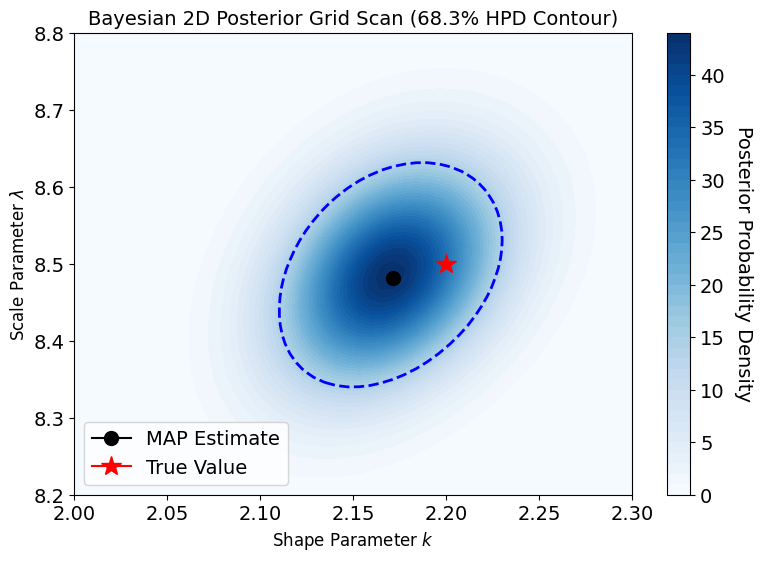

In [ ]:
plt.figure(figsize=(9, 6))

# Draw the colored shade for the 2D Posterior landscape
# We use 'Blues' to distinguish it from the 'binary' NLL plot,
# but keep the same dense contour level structure.
contour_shade = plt.contourf(K, LAM, posterior_2d, levels=45, cmap='Blues')
cbar = plt.colorbar(contour_shade)
cbar.set_label('Posterior Probability Density', rotation=270, labelpad=20)

# Draw the specific contour line for the 68.3% HPD region
# Styled exactly like the 2DeltaNLL=1 contour from the frequentist notebook
contour_line = plt.contour(K, LAM, posterior_2d, levels=[hpd_threshold_68],
                           colors='blue', linestyles='dashed', linewidths=2)

# Overlay the MAP Estimate
plt.plot(k_map, lam_map, marker='.', markersize=20, color='k', label='MAP Estimate')

# Overlay the True Value
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15,
         color='red', label='True Value', zorder=5)

plt.xlim(2.0, 2.3)
plt.ylim(8.2, 8.8)

plt.xlabel(r"Shape Parameter $k$", fontsize=12)
plt.ylabel(r"Scale Parameter $\lambda$", fontsize=12)
plt.title(r"Bayesian 2D Posterior Grid Scan (68.3% HPD Contour)", fontsize=14)
plt.legend(loc='lower left')

plt.show()
#@title { vertical-output: true}

# Bayesian Posterior using Accept-Reject Monte Carlo

Instead of evaluating the exact probability on a perfectly spaced grid, we can use Monte Carlo methods to draw samples directly from our posterior distribution.

The most fundamental method is **Rejection Sampling** (or the Accept-Reject algorithm).
1. We define a uniform **Proposal Distribution** that bounds our parameter space of interest (acting as a uniform prior).
2. We draw random parameter pairs $(k, \lambda)$ from this proposal distribution.
3. For each sampled pair, we calculate the unnormalized posterior probability density.
4. We scale the probabilities such that the maximum is 1.0.
5. We draw an auxiliary uniform random variable $u \sim U(0, 1)$ for each pair. If $u$ is less than the scaled posterior probability, we **accept** the sample. Otherwise, we **reject** it.

This method yields perfectly distributed posterior samples, but we will examine its computational efficiency.

In [ ]:
# --- 1. Define the Proposal Distribution (Uniform Prior limits) ---
k_min, k_max = 2.0, 2.3
lam_min, lam_max = 8.2, 8.8

N_proposals = 50000
print(f"Drawing {N_proposals} samples from the uniform proposal distribution...")

# --- 2. Draw the proposed parameter samples ---
np.random.seed(42)
k_proposed = np.random.uniform(k_min, k_max, N_proposals)
lam_proposed = np.random.uniform(lam_min, lam_max, N_proposals)

# --- 3. Evaluate the Log-Likelihood for each proposed sample ---
log_likelihoods = np.zeros(N_proposals)

# (Evaluating iteratively for clarity, though this can be vectorized)
for i in range(N_proposals):
    log_likelihoods[i] = np.sum(weibull_min.logpdf(wind_speeds, c=k_proposed[i], scale=lam_proposed[i]))

# --- 4. Scale to Unnormalized Posterior Probabilities ---
# We subtract the maximum log-likelihood before exponentiating.
# This sets the global maximum probability exactly to 1.0, establishing our acceptance envelope.
shifted_log_L = log_likelihoods - np.max(log_likelihoods)
probabilities = np.exp(shifted_log_L)

# --- 5. The Acceptance Criterion ---
# Draw the auxiliary uniform variable u ~ U(0, 1)
u_vals = np.random.uniform(0, 1.0, N_proposals)

# Apply the condition: Accept if u < P(k, lambda | Data)
accepted_mask = u_vals < probabilities

k_accepted = k_proposed[accepted_mask]
lam_accepted = lam_proposed[accepted_mask]

# --- 6. Results & Efficiency ---
n_accepted = len(k_accepted)
efficiency = (n_accepted / N_proposals) * 100

print(f"\n--- Rejection Sampling Results ---")
print(f"Total Proposals: {N_proposals}")
print(f"Accepted Samples: {n_accepted}")
print(f"Sampling Efficiency: {efficiency:.2f}%")

Drawing 50000 samples from the uniform proposal distribution...

--- Rejection Sampling Results ---
Total Proposals: 50000
Accepted Samples: 6347
Sampling Efficiency: 12.69%


## Visualizing the Posterior PDF with the accepted samples

If the rejection sampling algorithm converged properly, the spatial distribution of the accepted samples will perfectly approximate the 2D posterior probability contours we found in the Grid Approximation.

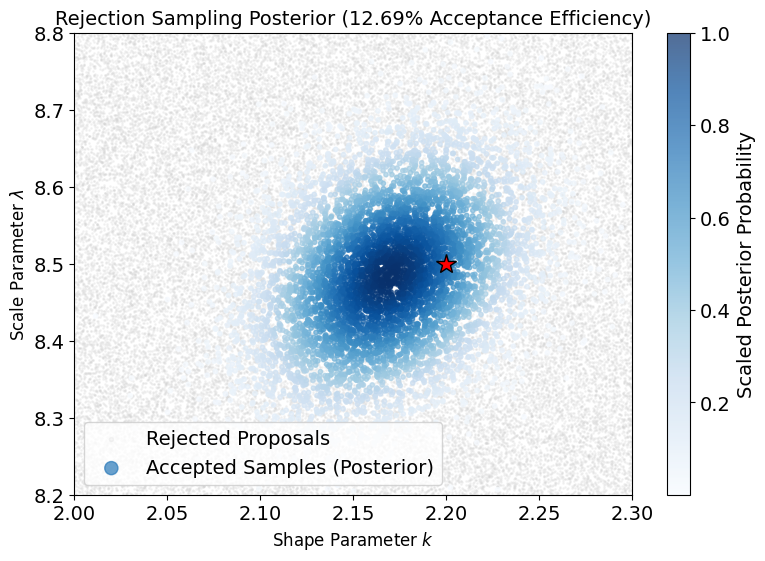

In [ ]:
plt.figure(figsize=(9, 6))

# Plot the rejected samples to visualize the bounds of the proposal distribution
plt.scatter(k_proposed[~accepted_mask], lam_proposed[~accepted_mask],
            color='lightgrey', alpha=0.2, s=1, label='Rejected Proposals')

# Plot the accepted samples, colored by their unnormalized posterior density
scatter = plt.scatter(k_accepted, lam_accepted,
                      c=probabilities[accepted_mask], cmap='Blues',
                      alpha=0.7, s=10, label='Accepted Samples (Posterior)')

plt.colorbar(scatter, label='Scaled Posterior Probability')

# Overlay the True Value
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15,
         color='red', markeredgecolor='black')

plt.xlim(k_min, k_max)
plt.ylim(lam_min, lam_max)

plt.xlabel(r"Shape Parameter $k$", fontsize=12)
plt.ylabel(r"Scale Parameter $\lambda$", fontsize=12)
plt.title(f"Rejection Sampling Posterior ({efficiency:.2f}% Acceptance Efficiency)", fontsize=14)

plt.legend(loc='lower left', markerscale=3)
plt.show()
#@title { vertical-output: true}

## Marginalisation

If you are interested in some parameters $\boldsymbol\mu$ (Parameters of Interest, or POIs) and want to disregard the others $\boldsymbol\nu$ (nuisance parameters), you marginalise the PDF by integrating over the nuisance parameters:
$$P(\boldsymbol\mu | \text{Data}) = \int P(\boldsymbol\mu, \boldsymbol\nu | \text{Data}) \, d\boldsymbol\nu$$

**However, if your posterior PDF is obtained from Monte Carlo sampling, then you do not need to do any integrals to marginalise!** You simply plot the 1D histogram of your POI and entirely ignore the values of the other parameters. Because the samples were drawn from the joint distribution, their 1D density naturally and automatically accounts for the integrated volume of the nuisance parameters.

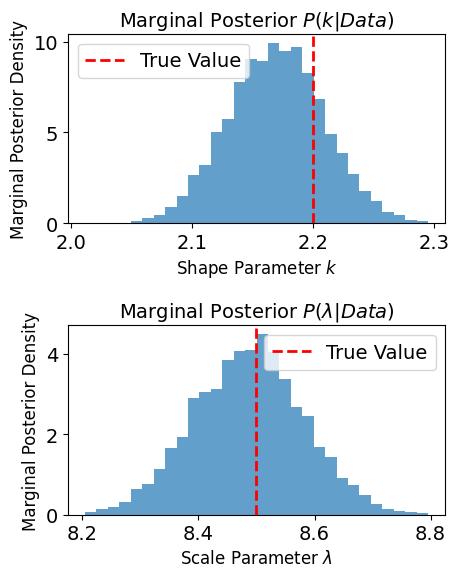

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(5, 6))

# --- Marginal PDF for k (ignoring lambda) ---
axes[0].hist(k_accepted, bins=30, density=True, alpha=0.7)
axes[0].axvline(true_shape_k, color='red', linestyle='dashed', linewidth=2, label='True Value')
axes[0].set_xlabel(r"Shape Parameter $k$", fontsize=12)
axes[0].set_ylabel("Marginal Posterior Density", fontsize=12)
axes[0].set_title(r"Marginal Posterior $P(k | Data)$", fontsize=14)
axes[0].legend()

# --- Marginal PDF for lambda (ignoring k) ---
axes[1].hist(lam_accepted, bins=30, density=True, alpha=0.7)
axes[1].axvline(true_scale_lam, color='red', linestyle='dashed', linewidth=2, label='True Value')
axes[1].set_xlabel(r"Scale Parameter $\lambda$", fontsize=12)
axes[1].set_ylabel("Marginal Posterior Density", fontsize=12)
axes[1].set_title(r"Marginal Posterior $P(\lambda | Data)$", fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
#@title { vertical-output: true}

In [ ]:
!pip install corner

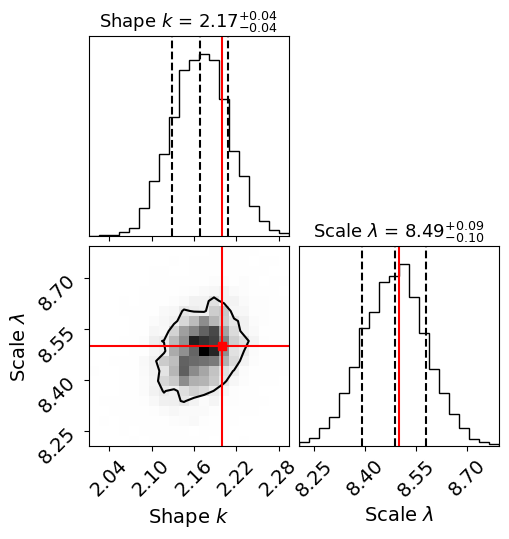

In [ ]:
## Plotting the posterior
import corner

# the corner package allows to plot posteriors that were obtained with MC sampling
# it will plot all pairs of parameters with their confidence region
# and also all the marginalisation over each parameter

# Stack the two 1D arrays into a single 2D array of columns
samples = np.column_stack((k_accepted, lam_accepted))

fig = corner.corner(
    samples,
    labels=[r"Shape $k$", r"Scale $\lambda$"],
    truths=[true_shape_k, true_scale_lam],
    levels=[0.683],
    truth_color='red',
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    plot_datapoints=False,
    title_kwargs={"fontsize": 13}
)

plt.show()
#@title { vertical-output: true}


## Sampling the Posterior with MCMC (`emcee` library)

As we saw, Accept-Reject sampling is highly inefficient. If we move to a model with 10 parameters, the acceptance rate drops to essentially zero.

To solve the "Curse of Dimensionality," physicists use **Markov Chain Monte Carlo (MCMC)** algorithms. Instead of guessing blindly, MCMC sets up "walkers" that explore the parameter space by preferring to step "uphill" toward regions of higher probability, while still occasionally stepping downhill to map out the tails.

We will use the **`emcee`** Python library, which is the standard tool in the physics and astronomy communities. It uses an "ensemble" of walkers that share information to efficiently map the posterior.

In [ ]:
!pip install emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
# 1. Define the Prior
def log_prior(theta):
    k, lam = theta
    # We use the same uniform bounds we used for our Rejection Sampling box
    if 2.0 < k < 2.3 and 8.2 < lam < 8.8:
        return 0.0 # log(1) = 0
    return -np.inf # log(0) = -infinity (Strictly forbidden)

# 2. Define the Likelihood (Same as before)
def log_likelihood(theta, data):
    k, lam = theta
    return np.sum(weibull_min.logpdf(data, c=k, scale=lam))

# 3. Define the Full Posterior
def log_posterior(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

In [ ]:
# --- Setup the emcee Sampler ---
import emcee

ndim = 2           # Number of parameters (k, lambda)
nwalkers = 50      # Number of independent MCMC chains (walkers)
nsteps = 3000      # How many steps each walker will take

# Initialize the walkers with small random offsets near a reasonable guess
# (Or we can scatter them uniformly across our prior box)
np.random.seed(42)
initial_k = np.random.uniform(2.1, 2.3, nwalkers)
initial_lam = np.random.uniform(8.3, 8.7, nwalkers)
initial_state = np.column_stack((initial_k, initial_lam))

# Create the sampler object
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[wind_speeds])

# --- Run the MCMC ---
print(f"Running {nwalkers} walkers for {nsteps} steps each...")
sampler.run_mcmc(initial_state, nsteps, progress=True)

Running 50 walkers for 3000 steps each...


100%|██████████| 3000/3000 [00:55<00:00, 54.07it/s]

Sampling complete!


In [ ]:
# --- Process the MCMC Output ---
# Discard the "Burn-in" phase (the steps taken while the walkers found the peak)
discard_steps = 500

# Extract the "flat" chain (combines all 32 walkers into one long list of samples)
flat_samples = sampler.get_chain(discard=discard_steps, flat=True)

print(f"Total usable samples obtained: {len(flat_samples)}")

Total usable samples obtained: 125000


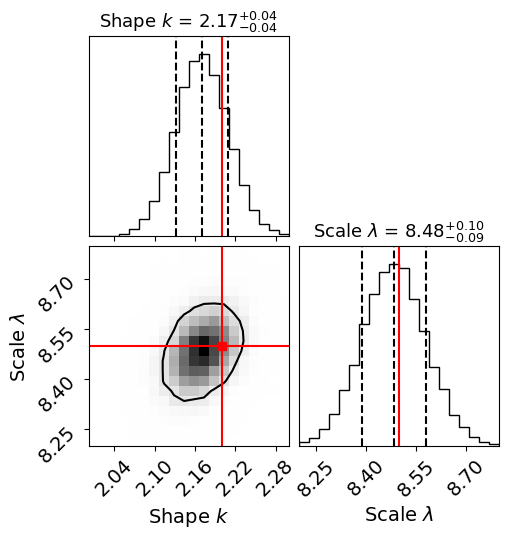

In [ ]:
# --- Plot the Results using Corner ---
fig = corner.corner(
    flat_samples,
    labels=[r"Shape $k$", r"Scale $\lambda$"],
    truths=[true_shape_k, true_scale_lam],
    levels=[0.683],
    truth_color='red',
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    plot_datapoints=False,
    title_kwargs={"fontsize": 13}
)
plt.show()
#@title { vertical-output: true}